# **1. Perkenalan Dataset**

Notebook ini digunakan untuk melakukan eksperimen awal pada dataset **Pima Indians Diabetes Dataset**.

Tujuan eksperimen:
- Memuat dataset mentah.
- Melakukan Exploratory Data Analysis (EDA).
- Melakukan preprocessing data.
- Menyimpan dataset hasil preprocessing agar siap digunakan untuk training model.

## Sumber Dataset

Dataset yang digunakan adalah **Pima Indians Diabetes Dataset**.

Dataset ini digunakan untuk memprediksi apakah seseorang memiliki indikasi diabetes atau tidak berdasarkan beberapa fitur medis.

Kolom target:
- `Outcome`
  - `0` = tidak diabetes
  - `1` = diabetes

# **2. Import Library**

Pada tahap ini, kita mengimpor library Python yang dibutuhkan untuk membaca data, eksplorasi data, visualisasi, dan preprocessing.

In [31]:

%pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, dataset mentah disimpan ke folder `namadataset_raw`, lalu dimuat dari folder tersebut.

Kode di bawah akan otomatis mengunduh dataset jika file `diabetes.csv` belum ada.

In [33]:
raw_dir = "../namadataset_raw"
raw_path = os.path.join(raw_dir, "diabetes.csv")

os.makedirs(raw_dir, exist_ok=True)

url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"

if not os.path.exists(raw_path):
    df_download = pd.read_csv(url)
    df_download.to_csv(raw_path, index=False)
    print("Dataset berhasil diunduh dan disimpan ke:", raw_path)
else:
    print("Dataset sudah tersedia di:", raw_path)

Dataset sudah tersedia di: ../namadataset_raw\diabetes.csv


In [34]:
df = pd.read_csv(raw_path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [35]:
df.shape

(768, 9)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [37]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [38]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita memahami isi dataset, mengecek missing value, mengecek data duplikat, melihat distribusi target, dan melihat korelasi antar fitur.

In [39]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [40]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [43]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

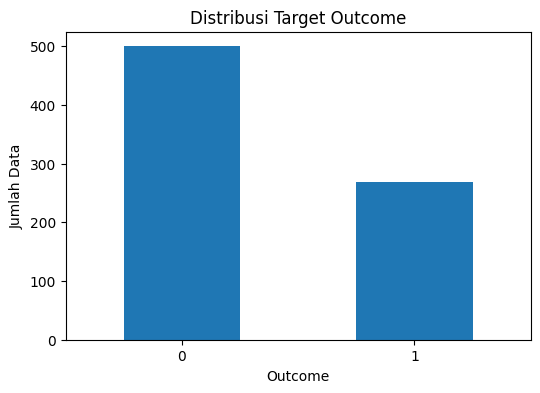

In [44]:
plt.figure(figsize=(6, 4))
df["Outcome"].value_counts().plot(kind="bar")
plt.title("Distribusi Target Outcome")
plt.xlabel("Outcome")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

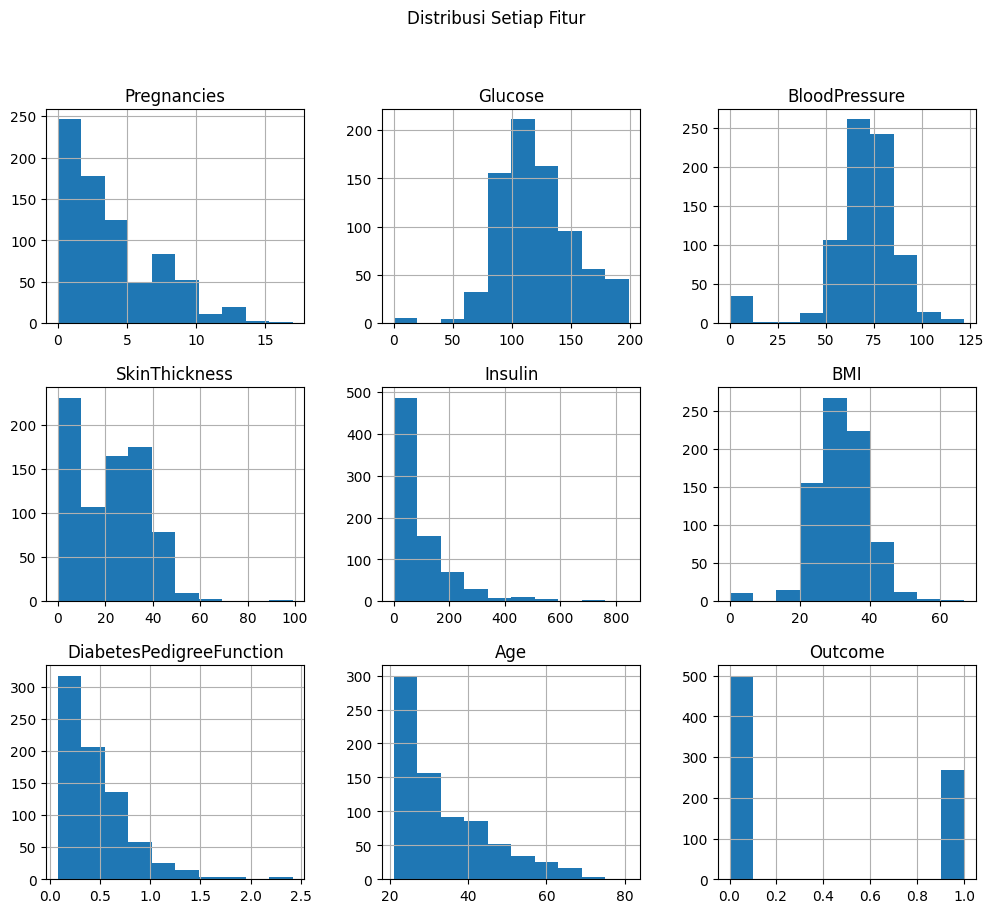

In [45]:
df.hist(figsize=(12, 10))
plt.suptitle("Distribusi Setiap Fitur")
plt.show()

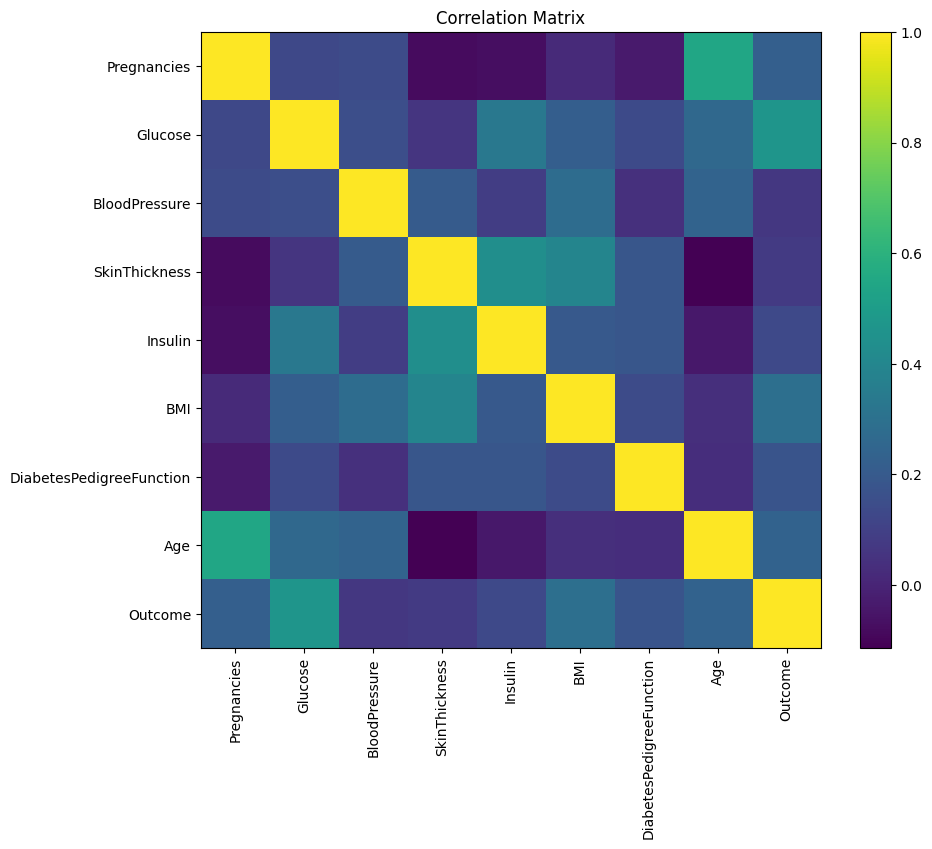

In [46]:
plt.figure(figsize=(10, 8))
plt.imshow(df.corr(), cmap="viridis", aspect="auto")
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.title("Correlation Matrix")
plt.show()

In [47]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    print(col, "jumlah nilai 0:", (df[col] == 0).sum())

Glucose jumlah nilai 0: 5
BloodPressure jumlah nilai 0: 35
SkinThickness jumlah nilai 0: 227
Insulin jumlah nilai 0: 374
BMI jumlah nilai 0: 11


Berdasarkan EDA, dataset memiliki target klasifikasi biner, yaitu kelas `0` dan `1`.

Beberapa kolom seperti `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI` memiliki nilai `0`. Dalam konteks medis, nilai 0 pada kolom-kolom tersebut kurang masuk akal, sehingga pada tahap preprocessing nilai tersebut akan diganti menggunakan median.

# **5. Data Preprocessing**

Pada tahap ini, kita membersihkan data agar siap digunakan untuk pelatihan model.

Tahapan preprocessing:
1. Menyalin dataset asli.
2. Menghapus data duplikat.
3. Mengganti nilai 0 yang tidak wajar pada beberapa kolom medis dengan median.
4. Memisahkan fitur dan target.
5. Membagi data menjadi train dan test.
6. Melakukan standardisasi fitur numerik.

In [48]:
df_preprocess = df.copy()
df_preprocess.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [49]:
df_preprocess = df_preprocess.drop_duplicates()
df_preprocess.shape

(768, 9)

In [50]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    median_value = df_preprocess.loc[df_preprocess[col] != 0, col].median()
    df_preprocess[col] = df_preprocess[col].replace(0, median_value)

df_preprocess[zero_columns].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.656250,72.386719,29.108073,140.671875,32.455208
std,30.438286,12.096642,8.791221,86.383060,6.875177
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,121.500000,27.500000
50%,117.000000,72.000000,29.000000,125.000000,32.300000
75%,140.250000,80.000000,32.000000,127.250000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


In [51]:
X = df_preprocess.drop(columns=["Outcome"])
y = df_preprocess["Outcome"]

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,125,33.6,0.627,50
1,1,85,66,29,125,26.6,0.351,31
2,8,183,64,29,125,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [52]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", X_train.shape)
print("Jumlah data testing:", X_test.shape)

Jumlah data training: (614, 8)
Jumlah data testing: (154, 8)


In [54]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169
1,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034
2,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594
3,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293
4,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320


In [55]:
train_data = X_train_scaled.copy()
train_data["Outcome"] = y_train.reset_index(drop=True)

test_data = X_test_scaled.copy()
test_data["Outcome"] = y_test.reset_index(drop=True)

train_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169,0
1,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034,0
2,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594,0
3,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293,0
4,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320,0


# **6. Simpan Dataset Hasil Preprocessing**

Dataset hasil preprocessing disimpan ke folder `namadataset_preprocessing`.

File yang dihasilkan:
- `train_data.csv`
- `test_data.csv`
- `diabetes_preprocessing.csv`

In [56]:
output_dir = "namadataset_preprocessing"
os.makedirs(output_dir, exist_ok=True)

train_data.to_csv(os.path.join(output_dir, "train_data.csv"), index=False)
test_data.to_csv(os.path.join(output_dir, "test_data.csv"), index=False)

full_preprocessed = pd.concat([train_data, test_data], axis=0)
full_preprocessed.to_csv(os.path.join(output_dir, "diabetes_preprocessing.csv"), index=False)

print("Dataset hasil preprocessing berhasil disimpan.")

Dataset hasil preprocessing berhasil disimpan.


In [57]:
os.listdir("namadataset_preprocessing")

['diabetes_preprocessing.csv', 'test_data.csv', 'train_data.csv']